# RAG Modern BERT Advanced Evaluation

This notebook compares the accuracy of the advanced BERT hybrid pipeline across different subjects and grade ranges (1-6 and 7-12).

## 1. Load Data

Load the evaluation results from the CSV file. The file should contain columns for question, choices, ground_truth_index, predicted_index, grade, subject, and correctness.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the evaluation results
csv_path = '../data/advanced_bert_hybrid_results.csv'
df = pd.read_csv(csv_path)
df.head()

,question,choices,ground_truth_index,predicted_index,grade,subject,is_correct
0,Which figure of speech is used in this text?\n...,"['paradox', 'oxymoron']",0,1.0,grade11,language science,False
1,Which of the following contains a vague pronou...,"[""If Lila's skirt doesn't match the blouse, sh...",1,NaN,grade11,language science,False
2,Which text message is more formal?,"[""Ms. Norton is already here. She's waiting in...",0,1.0,grade11,language science,False
3,Which logical fallacy is used in the text?\nSo...,"[""straw man: a misrepresentation of an opponen...",0,1.0,grade11,language science,False
4,Which figure of speech is used in this text?\n...,"['anaphora', 'hyperbole']",1,2.0,grade11,language science,False


## 2. Prepare Grade Ranges

Split the dataset into grades 1-6 (primary) and grades 7-12 (secondary) for analysis.

In [8]:
# Convert grade column to numeric (extract digits)
def extract_grade(grade_str):
    import re
    match = re.search(r'(\d+)', str(grade_str))
    return int(match.group(1)) if match else None

df['grade_num'] = df['grade'].apply(extract_grade)

grade_1_6 = df[df['grade_num'].between(1, 6)]
grade_7_12 = df[df['grade_num'].between(7, 12)]

## 3. Calculate Accuracy by Subject and Grade Range

Compute the accuracy for each subject within grades 1-6 and 7-12.

In [9]:
def subject_accuracy(df):
    return df.groupby('subject')['is_correct'].mean()

accuracy_1_6 = subject_accuracy(grade_1_6)
accuracy_7_12 = subject_accuracy(grade_7_12)

accuracy_df = pd.DataFrame({
    'Grades 1-6': accuracy_1_6,
    'Grades 7-12': accuracy_7_12
}).fillna(0)
accuracy_df

,Grades 1-6,Grades 7-12
subject,,
language science,0.365751,0.253546
natural science,0.328515,0.287273
social science,0.307692,0.222222


## 4. Visualize Accuracy Comparison by Subject

Bar chart comparing accuracy for each subject between grades 1-6 and 7-12.

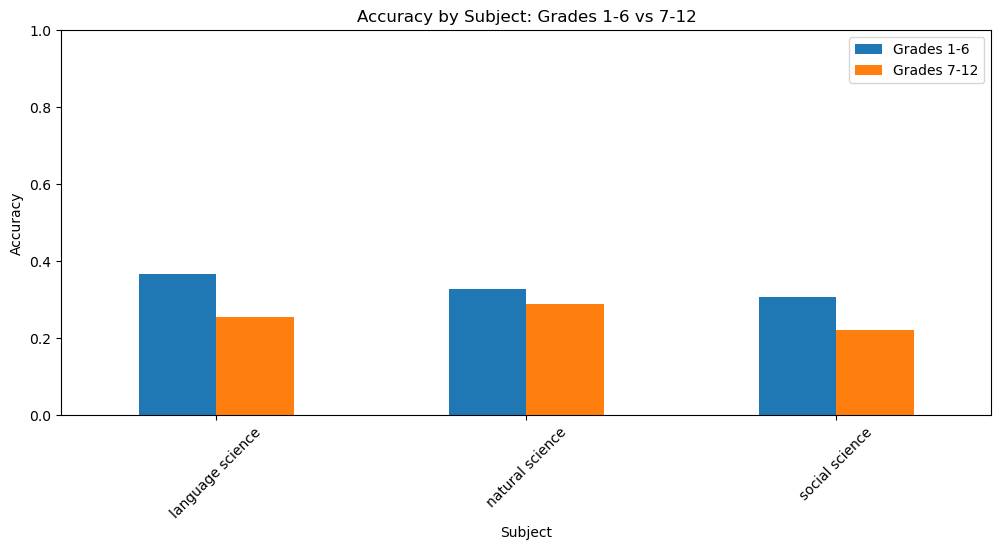

In [10]:
accuracy_df.plot(kind='bar', figsize=(12,5))
plt.title('Accuracy by Subject: Grades 1-6 vs 7-12')
plt.ylabel('Accuracy')
plt.xlabel('Subject')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 5. Summary and Interpretation

This analysis compares the accuracy of the advanced BERT hybrid pipeline across subjects and grade ranges. Use the results to identify strengths and weaknesses in model performance for specific subjects and educational levels.

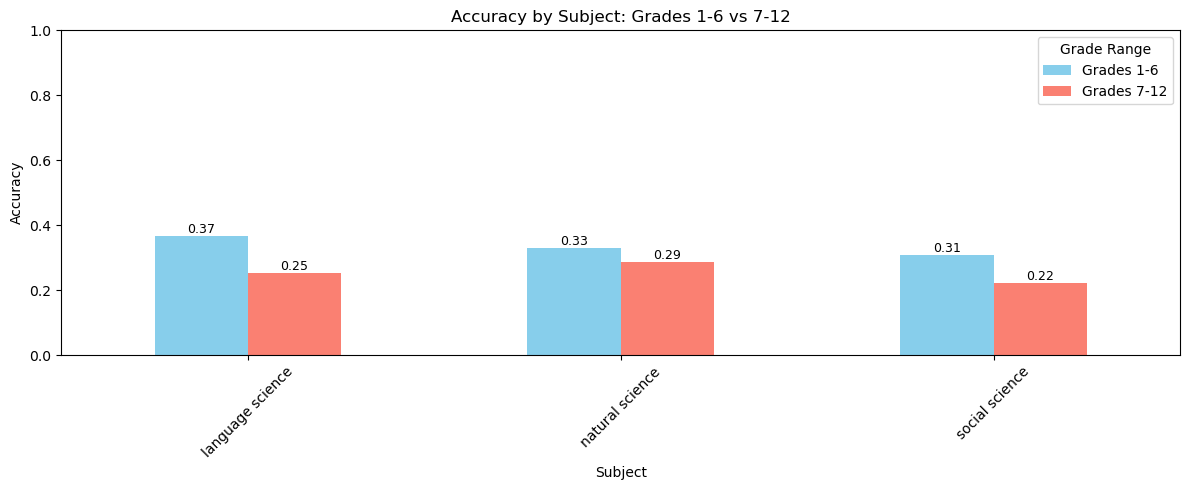

In [11]:
ax = accuracy_df.plot(kind='bar', figsize=(12,5), color=['skyblue', 'salmon'])
plt.title('Accuracy by Subject: Grades 1-6 vs 7-12')
plt.ylabel('Accuracy')
plt.xlabel('Subject')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='Grade Range')

# Annotate accuracy values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.tight_layout()
plt.show()